# Image Processing Lab 2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/Image Processing Lab 2/'
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Introduction. Complex Numbers in Python
Matlab work naturally with the floating point representation of complex numbers.  The accuracy is about 16 decimal digits.  Try to understand the results of the following:

In [3]:
#import numpy as np
import cmath
a = 1.5
b = 0.8
c = a + b*1j
print(c)
c2 = complex(a,b)
print(c2)


(1.5+0.8j)
(1.5+0.8j)


You can relate the obtained results with the following image relating the Euler's formula:


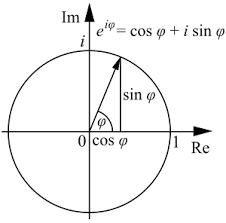



In [4]:
import numpy as np

print(c.real)
print(c.imag)
print(cmath.sqrt(-1))
print((1j)**2)
print(cmath.exp(cmath.pi*1j))
print ("The phase of complex number is :" , cmath.phase(c))

1.5
0.8
1j
(-1+0j)
(-1+1.2246467991473532e-16j)
The phase of complex number is : 0.48995732625372834


In [5]:
x = 1j**(1/3)
print(x.real)
print(x.imag)
print(abs(x))
print(c * c2)

0.8660254037844387
0.49999999999999994
1.0
(1.6099999999999999+2.4000000000000004j)


# Experiments with Fourier transforms
In Python we use the fft2() function calculates the fast Fourier transform of an image, and the ifft2() function to calculates the inverse transform within scipy package.

During the seminar 3 we have computed the fourier transform of several 2D signals, that can be seen as an image. Let's try to compute the same fourier transform and relate the results:

First we define the 2D signal:

In [6]:
from scipy.fft import fft2, ifft2, fftshift, fft, ifft

x = np.zeros((2,3))
x[0,0] = 100
print(x)
#Let's compute the fourier transforms of the 2D signal:
fx = fft2(x)
print(fx)
#And now the inverse of the fourier transform:
print(ifft2(fx))

[[100.   0.   0.]
 [  0.   0.   0.]]
[[100.-0.j 100.+0.j 100.-0.j]
 [100.-0.j 100.+0.j 100.-0.j]]
[[100.+0.j   0.+0.j   0.-0.j]
 [  0.+0.j   0.+0.j   0.+0.j]]


# Visualization of the Fourier transform
The Fourier transform of a small matrix could be analyzed by direct inspection of each matrix entry (these numbers are generally complex). But for visualization a large matrix of complex numbers must be somehow transformed into a real image. Some part of information is inevitably lost.  During this lab, we propose to apply the transformation  (but there are many other ways of visualization).  
Let us define this transformation in code. 
For example, the definition could be:


function g=logvis(f)
   g=log(1+abs(f);
end

Furthermore, we propose to define an auxiliary function for normalizing the values of a matrix to fall within 0 and 1.


function g = normalize(f)
    g=(f-min(f(:)))/(max(f(:))-min(f(:)));
end


During the lab session, it would be convenient that you create a function file for each function you will use often, like for example logvis and normalize. In this case I have created both functions for you. Nonetheless, you will need to create those functions too in your exercises.

Using these two functions we can more easily visualize the Fourier transforms:

In [7]:
#from sklearn.preprocessing import MinMaxScaler
def logvis(f):
  g = np.log(1 + abs(f))
  return g

#scaler = MinMaxScaler()
def normalize(X):
  g = (X - X.min()) / (X.max() - X.min()) 
  return g


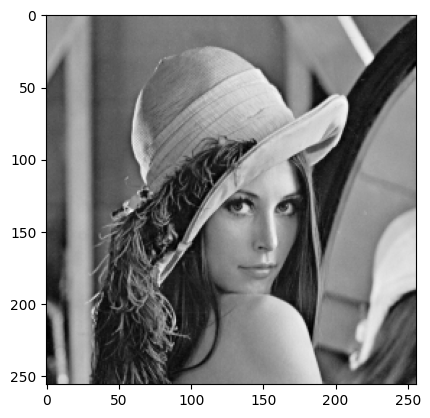

In [8]:
#Read the image in Double
lena = mpimg.imread(path+"lena.png")
plt.imshow(lena, cmap="gray")

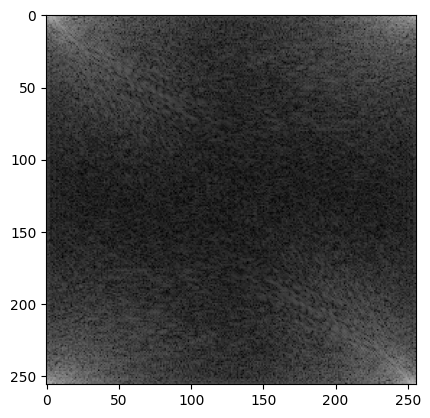

In [9]:
#compute the fourier transform
fx_lena = fft2(lena)
#show the fourier transform of the image with the transformation explained
fx_vis = normalize(logvis(fx_lena))
plt.imshow(fx_vis, cmap="gray")


It is common "to center" the Fourier transform so that the origin of coordinates remains in the center of the image, instead of the upper left corner.

The function fftshift from scipy package performs this shift.  Combining all these functions, we define a function to display Fourier transforms:


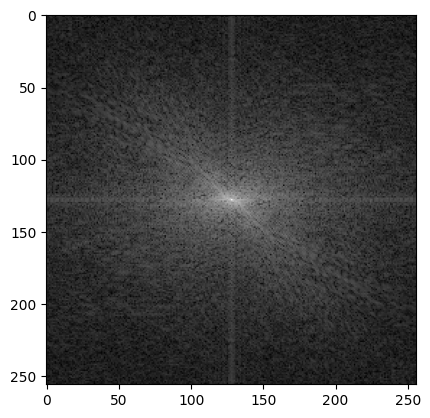

In [10]:
plt.imshow(fftshift(fx_vis), cmap="gray")

In [11]:
def visualize(f):
  g = fftshift(normalize(logvis(f)))
  plt.imshow(g, cmap="gray")

# Interpretation of the Fourier transform.
The smoother an image is, that is, the lower frequencies it has, the more its spectrum is concentrated around the origin. In the extreme case of a constant image, the only one non-zero value of the spectrum is at the origin. If an image is very noisy or has periodic high frequency components, the spectrum is more dispersed. For example, if you compare the following image of barbara to the image of lena, barbara image contains higher frequencies than the   lena image  (high frequencies correspond to the periodic texture of the striped dress and the wicker chair):

(1686, 1683)

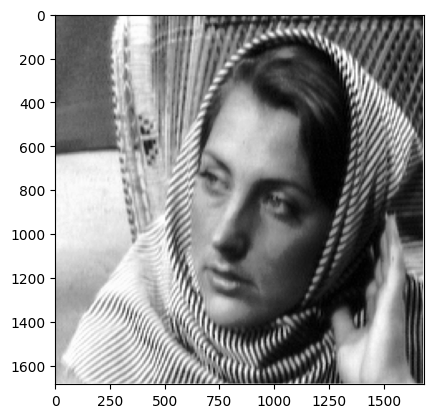

In [12]:
#from PIL import Image
#Read the image in Double
bar = mpimg.imread(path+"Barbara.png")
# be sure is one channel image
bar = bar[:,:,0]
#bar = bar*255
plt.imshow(bar, cmap="gray")
bar.shape


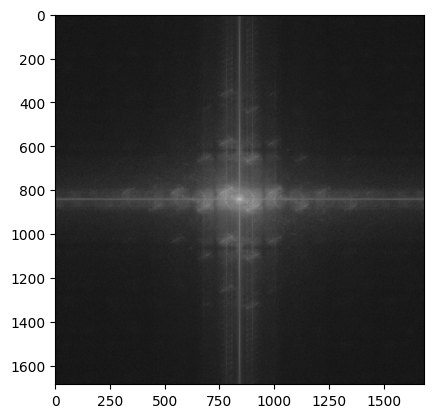

In [13]:
# compute the fourier transform
fx_bar = fft2(bar)
visualize(fx_bar)

# Frequency Filters
 
The simplest application of the frequency domain is the direct editing of an image frequencies. The low-pass filter  aims to eliminate high frequencies and the high-pass filter aims to eliminate low frequencies. The band-pass filter retain only frequencies within a certain range.
It is important to familiarize yourself with the effects that these filters produce on images. We provide a function claled lpfilter that creates a filter, which is simply a binary mask that is then applied to the frequencies:

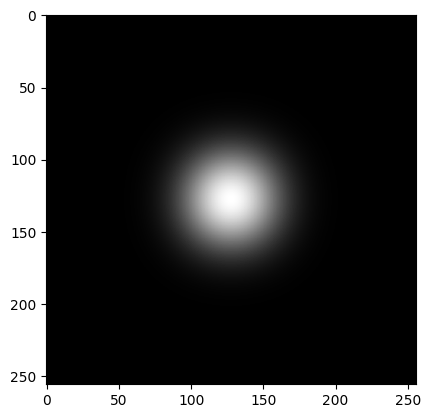

In [14]:
# define low pass filter

r = 13 # how narrower the window is
ham = np.hamming(256)[:,None] # 1D hamming
ham2d = np.sqrt(np.dot(ham, ham.T)) ** r
plt.imshow(ham2d, cmap="gray")

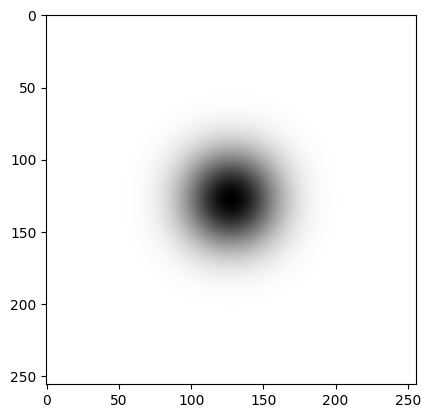

In [15]:
# the high pass filter is the inverse to the low pass filter
high_pass = 1 - ham2d
plt.imshow(high_pass, cmap="gray")
# Let's visualize the fourier transform  of the image lena when the low pass filter or high pass filter is applied

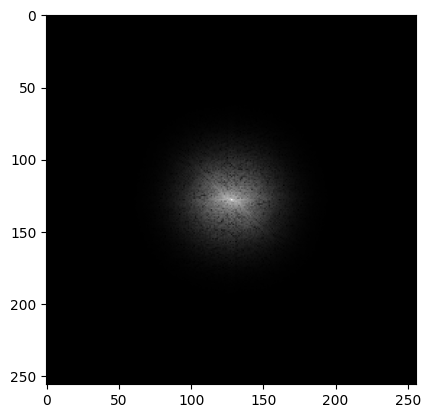

In [16]:
# % Let's visualize them
plt.imshow(fftshift(fx_vis)*ham2d, cmap="gray")

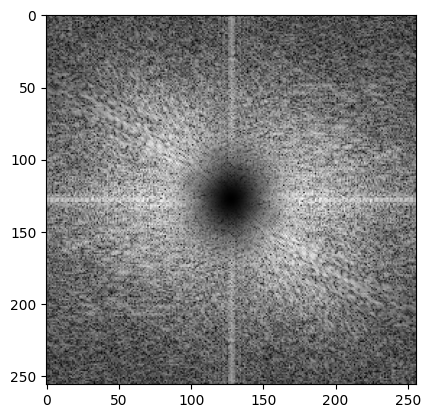

In [17]:
plt.imshow(fftshift(fx_vis)*high_pass, cmap="gray")

In [18]:
# Let's apply the inverse of the fourier transform

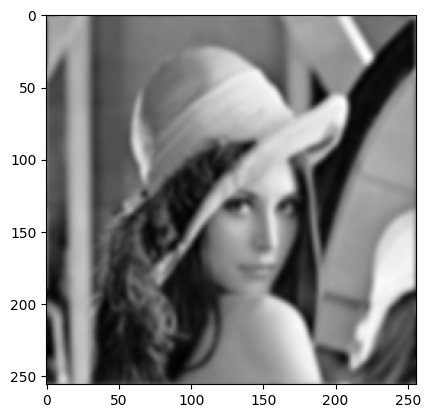

In [19]:
plt.imshow(ifft2(fx_lena * fftshift(ham2d)).real, cmap="gray")

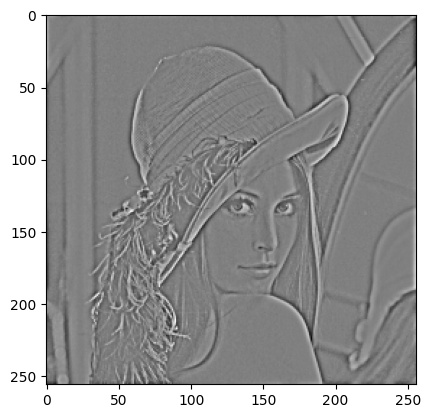

In [20]:
plt.imshow(ifft2(fx_lena * fftshift(high_pass)).real, cmap="gray")

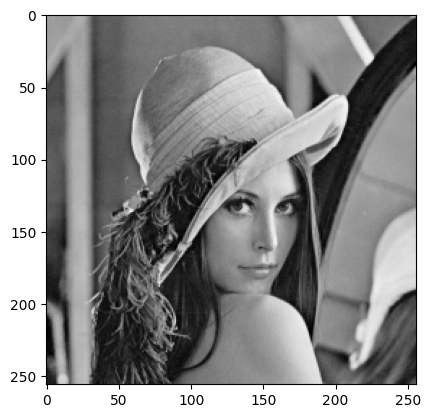

In [21]:
plt.imshow(ifft2(fx_lena * fftshift((high_pass+ham2d)/2)).real, cmap="gray")

You can see that the filtering sometimes has not a very good quality.
This is called ringing or Gibbs phenomenon, and it happens because a binary mask is not smooth.  
Later,  we will study this phenomenon in more details, and see how this issue can be solved by using Gaussian masks instead of a binary ones as we used in the last example.

On the other hand, band-pass filters can be obtained by combining two low-pass filters of different frequencies:

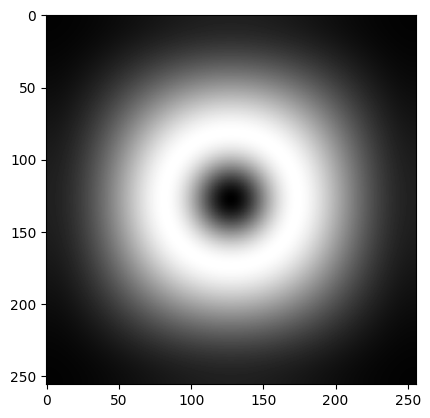

In [22]:
low_pass_new = 1-  np.sqrt(np.dot(ham, ham.T)) ** 2
high_pass_new = 1-  np.sqrt(np.dot(ham, ham.T)) ** 15 
band_pass = high_pass_new - low_pass_new
plt.imshow(band_pass, cmap="gray")

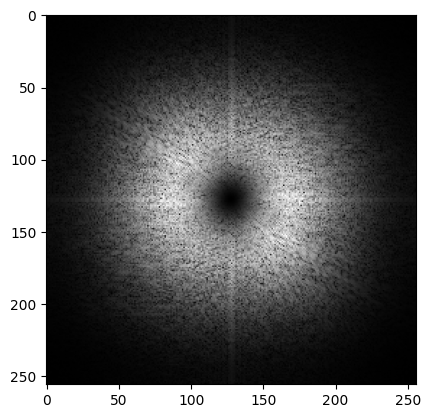

In [23]:
plt.imshow(fftshift(fx_vis)*band_pass, cmap="gray")

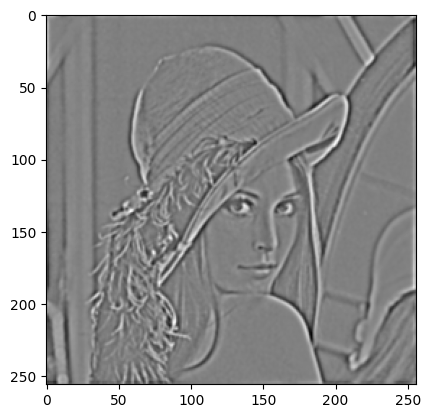

In [24]:
plt.imshow(ifft2(fx_lena * fftshift(band_pass)).real, cmap="gray")

# Sampling, aliasing, ringing, geometry of sampling

The operator ``:'' in Python greatly facilitates the implementation of sampling.:

In [25]:
# Create a random 1D signal
x = np.random.rand(10,10)
x

array([[0.49963752, 0.61276257, 0.31877937, 0.44012622, 0.28515783,
        0.51654193, 0.84429966, 0.94823381, 0.26581304, 0.35276123],
       [0.94756822, 0.49621854, 0.76273272, 0.56517728, 0.18706468,
        0.36108939, 0.80602053, 0.03655494, 0.92776153, 0.88226169],
       [0.81827938, 0.5244648 , 0.73548938, 0.73037697, 0.68404373,
        0.34105047, 0.06928537, 0.83110451, 0.92617356, 0.16553151],
       [0.62265004, 0.95211738, 0.66472202, 0.72547505, 0.48053597,
        0.7238764 , 0.86457819, 0.68006437, 0.84520158, 0.72164387],
       [0.17704686, 0.70631572, 0.43471177, 0.63236539, 0.50740249,
        0.8282913 , 0.71322875, 0.16754526, 0.48990399, 0.04789851],
       [0.40645587, 0.8567699 , 0.00319854, 0.82669366, 0.67438526,
        0.55214946, 0.35511059, 0.19629233, 0.44162707, 0.11346575],
       [0.57245472, 0.22550976, 0.32964723, 0.40162122, 0.10926089,
        0.15305218, 0.46767408, 0.83649403, 0.22185716, 0.6217283 ],
       [0.26608511, 0.23679169, 0.0351305

In [26]:
# Take just the first 5 values from column 1
x[:5,0]

array([0.49963752, 0.94756822, 0.81827938, 0.62265004, 0.17704686])

In [27]:
# Subsampling of factor two. Python array slicing definition--->> [start:end:step] always starts from 0 not 1
print("Subsampling only on first column", x[0:9:2,0])
print(x[0:9:2,0:9:2])

Subsampling only on first column [0.49963752 0.81827938 0.17704686 0.57245472 0.3962362 ]
[[0.49963752 0.31877937 0.28515783 0.84429966 0.26581304]
 [0.81827938 0.73548938 0.68404373 0.06928537 0.92617356]
 [0.17704686 0.43471177 0.50740249 0.71322875 0.48990399]
 [0.57245472 0.32964723 0.10926089 0.46767408 0.22185716]
 [0.3962362  0.78185396 0.97014784 0.73591165 0.0864811 ]]


This operator can be used to reduce the size of images (with loss of resolution).

(256, 256)
(128, 128)


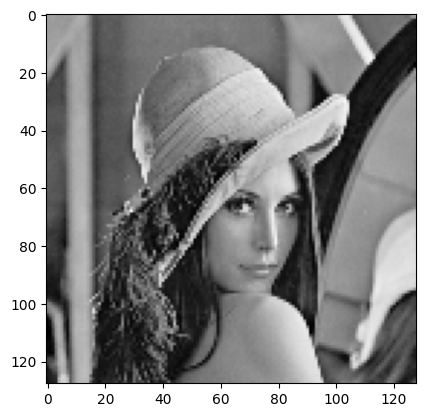

In [28]:
print(lena.shape)
lena_half = lena[0:255:2,0:255:2]
print(lena_half.shape)
plt.imshow(lena_half, cmap="gray")

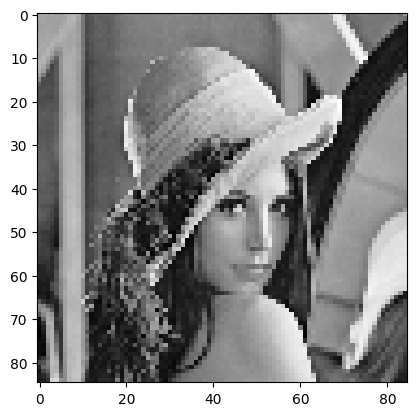

In [29]:
lena_third = lena[0:255:3,0:255:3]
lena_quatr = lena[0:255:4,0:255:4]
plt.imshow(lena_third, cmap="gray")


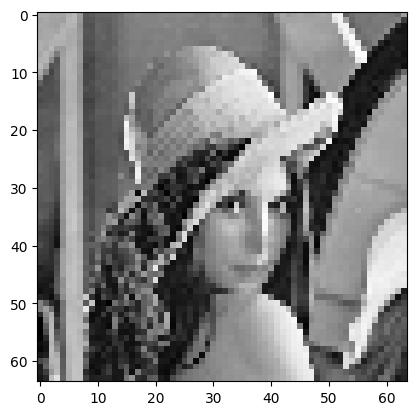

In [30]:
plt.imshow(lena_quatr, cmap="gray")

# Interpretation of sampling in the frequency space

In theory session you have seen that sampling in the spatial domain corresponds to the folding in the frequency domain (produce replications of the spectrum that can be layered or folded).
In the case of one dimension, it can be seen that:

In [31]:
# Random 1D signal of size N
N = 10
x = np.random.rand(N)
# Compute the fourier transform
fx = fft(x)
print(fx)
# middle position of the signal
mid_N = int(N/2)
# Folding
fx_small = (fx[:mid_N] + fx[mid_N:])/2

# inverse transform
x_folded = ifft(fx_small)
# Subsampling
x_2 = x[::2]
# diference between signal and subsmapling
x_folded - x_2

# Keep in mind that the results is close to 0 because is multiplyied by 10^{-15}

[ 5.96320232-0.j          0.4884138 -1.12903536j -0.12733302-0.39652177j
  0.20439449-0.71759684j  0.5376863 -0.46775782j  0.61504783-0.j
  0.5376863 +0.46775782j  0.20439449+0.71759684j -0.12733302+0.39652177j
  0.4884138 +1.12903536j]


array([0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j,
       1.11022302e-16+0.j, 0.00000000e+00+0.j])